In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

features = pd.read_parquet(DATA_PROCESSED / "features.parquet")
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

sup_latent_df = pd.read_parquet(
    DATA_LATENT / "supervised_cnn_vae_latents.parquet"
)

features.index = pd.to_datetime(features.index)
returns.index = pd.to_datetime(returns.index)
sup_latent_df["date"] = pd.to_datetime(sup_latent_df["date"])

sup_latent_df.head()

,date,ticker,target_return_10d,pred_return_10d,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,-0.038254,0.017117,-0.165311,1.134504,-1.445229,1.191268,0.838135,1.248731,-0.626914,-0.358154
1,2015-09-22,AAPL,-0.017760,0.017041,-0.240465,1.112205,-1.361434,1.288137,0.763379,1.212089,-0.619133,-0.295517
2,2015-09-23,AAPL,-0.030634,0.016867,-0.232379,1.105707,-1.205404,1.429420,0.567163,1.272981,-0.573612,-0.353675
3,2015-09-24,AAPL,-0.048136,0.016492,-0.165983,1.043628,-1.174774,1.460648,0.689822,1.340265,-0.535046,-0.214705
4,2015-09-25,AAPL,-0.021688,0.015912,-0.153574,1.114064,-1.045284,1.551994,0.410720,1.297225,-0.525672,-0.213376


In [3]:
z_cols = [c for c in sup_latent_df.columns if c.startswith("z_")]

z_cols

['z_0', 'z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7']

In [4]:
sup_latent_df[["target_return_10d", "pred_return_10d"] + z_cols].describe()

,target_return_10d,pred_return_10d,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
count,69780.000000,69780.000000,69780.000000,69780.000000,69780.000000,69780.000000,69780.000000,69780.000000,69780.000000,69780.000000
mean,0.010143,0.010153,0.053861,0.018356,-0.127609,0.043643,0.059163,0.005086,0.029267,-0.149795
std,0.061302,0.010135,1.010272,1.116511,1.237450,1.263497,1.050851,0.989583,1.192563,1.064965
min,-0.674452,-0.074066,-4.999921,-12.334913,-2.399003,-9.048963,-3.172577,-7.875182,-13.298688,-6.089263
25%,-0.019201,0.004765,-0.558447,-0.537100,-0.962940,-0.724479,-0.657419,-0.506597,-0.461096,-0.687306
50%,0.010683,0.008152,-0.033783,0.022988,-0.376047,-0.083409,-0.136124,0.028691,0.233437,-0.094012
75%,0.040036,0.013050,0.557099,0.607350,0.406766,0.668526,0.535722,0.520717,0.798295,0.453456
max,0.525885,0.119995,8.422939,6.113239,9.157383,8.452876,7.765749,7.175869,4.046864,8.484383


In [5]:
corr_pred_target = sup_latent_df["pred_return_10d"].corr(
    sup_latent_df["target_return_10d"]
)

corr_pred_target

np.float64(0.190186025801171)

In [6]:
sup_latent_df["year"] = sup_latent_df["date"].dt.year

yearly_corr = (
    sup_latent_df
    .groupby("year")
    .apply(lambda g: g["pred_return_10d"].corr(g["target_return_10d"]))
)

yearly_corr

/var/folders/fg/wgm47t3959l7xn17zm9k_5s80000gn/T/ipykernel_72599/2181621350.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sup_latent_df


year
2015    0.155271
2016    0.229255
2017    0.129911
2018    0.106257
2019    0.131389
2020    0.399740
2021    0.092153
2022    0.110878
2023    0.156344
2024    0.109983
dtype: float64

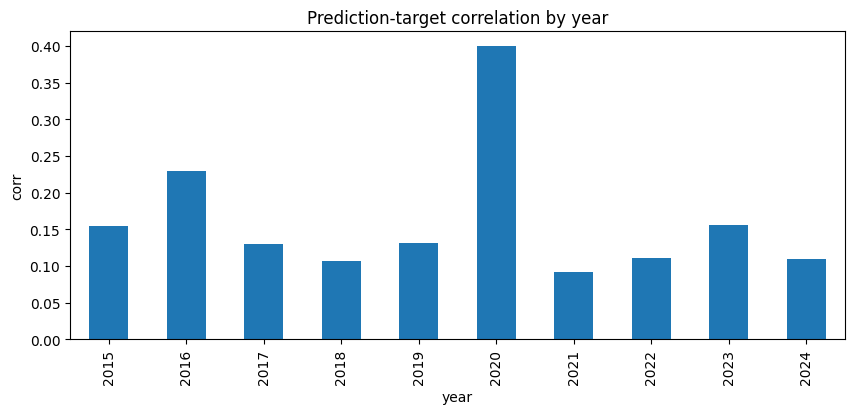

In [7]:
yearly_corr.plot(
    kind="bar",
    figsize=(10, 4),
    title="Prediction-target correlation by year"
)

plt.ylabel("corr")
plt.show()

In [8]:
latent_target_corr = pd.Series({
    z: sup_latent_df[z].corr(sup_latent_df["target_return_10d"])
    for z in z_cols
}).sort_values()

latent_target_corr

z_6   -0.088866
z_7   -0.047638
z_0   -0.021834
z_1   -0.014297
z_5   -0.003171
z_3    0.011538
z_2    0.059323
z_4    0.076389
dtype: float64

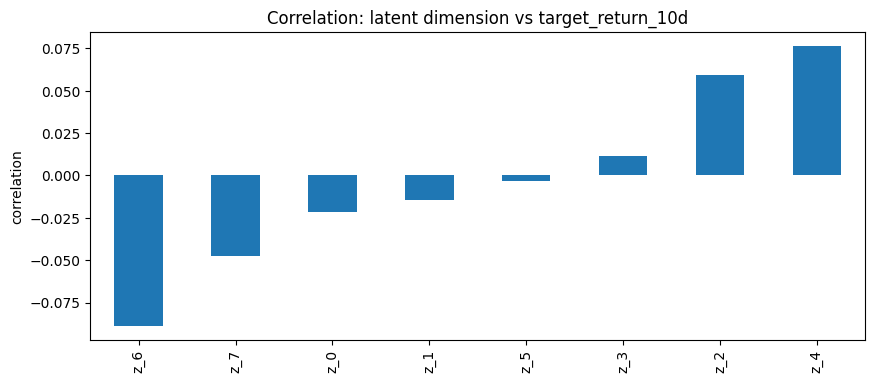

In [9]:
latent_target_corr.plot(
    kind="bar",
    figsize=(10, 4),
    title="Correlation: latent dimension vs target_return_10d"
)

plt.ylabel("correlation")
plt.show()

In [10]:
latent_pred_corr = pd.Series({
    z: sup_latent_df[z].corr(sup_latent_df["pred_return_10d"])
    for z in z_cols
}).sort_values()

latent_pred_corr

z_6   -0.566339
z_7   -0.326107
z_0   -0.113880
z_5   -0.047128
z_1   -0.036010
z_3    0.162064
z_2    0.324141
z_4    0.537203
dtype: float64

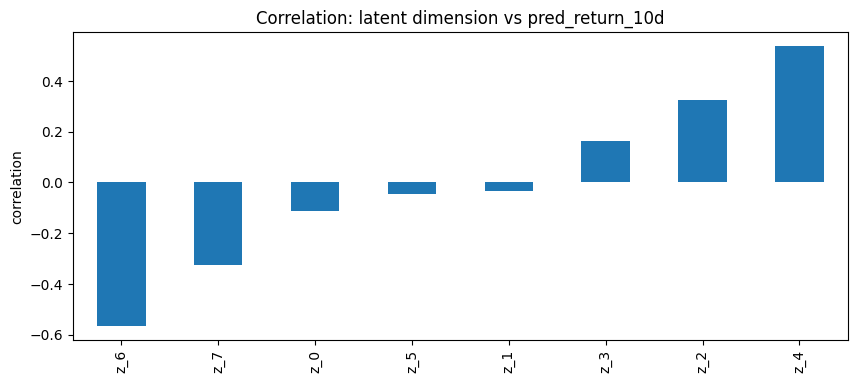

In [11]:
latent_pred_corr.plot(
    kind="bar",
    figsize=(10, 4),
    title="Correlation: latent dimension vs pred_return_10d"
)

plt.ylabel("correlation")
plt.show()

In [12]:
X = sup_latent_df[z_cols].values
y = sup_latent_df["target_return_10d"].values

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

ridge.fit(X, y)

coefs = ridge.named_steps["ridge"].coef_

ridge_coef_series = pd.Series(
    coefs,
    index=z_cols
).sort_values()

ridge_coef_series

z_6   -0.004628
z_7   -0.002559
z_0   -0.001806
z_5   -0.000514
z_3   -0.000170
z_1    0.000004
z_4    0.002096
z_2    0.002466
dtype: float32

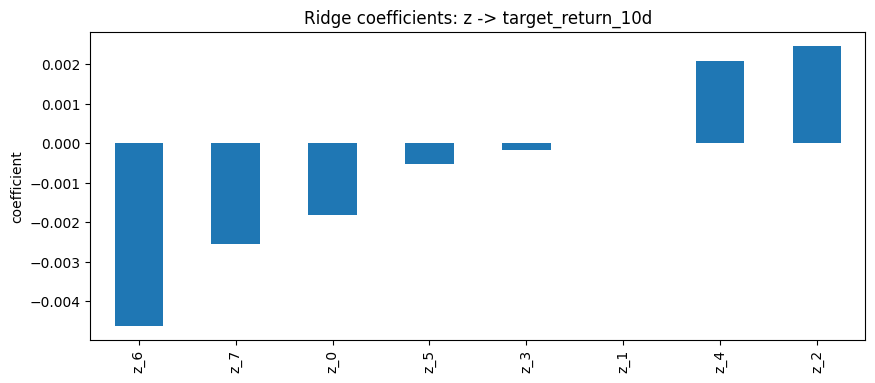

In [13]:
ridge_coef_series.plot(
    kind="bar",
    figsize=(10, 4),
    title="Ridge coefficients: z -> target_return_10d"
)

plt.ylabel("coefficient")
plt.show()

In [14]:
Z = sup_latent_df[z_cols].values

pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

sup_latent_df["pc1"] = Z_pca[:, 0]
sup_latent_df["pc2"] = Z_pca[:, 1]

pca.explained_variance_ratio_

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


array([0.23325387, 0.21673083], dtype=float32)

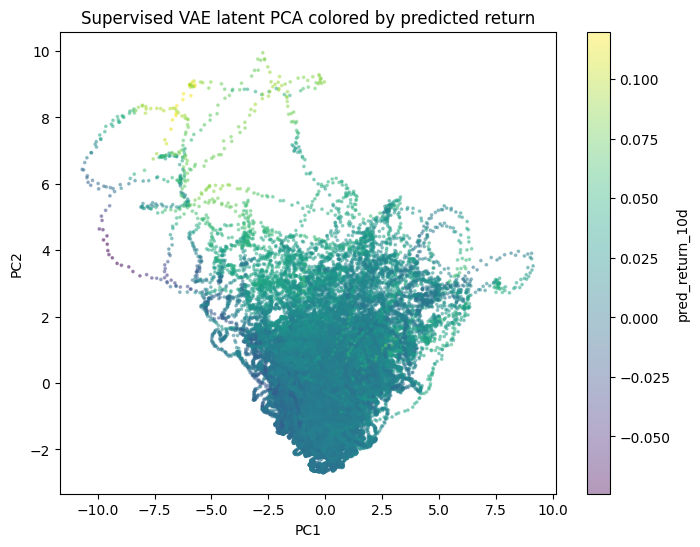

In [15]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    sup_latent_df["pc1"],
    sup_latent_df["pc2"],
    c=sup_latent_df["pred_return_10d"],
    s=3,
    alpha=0.4
)

plt.colorbar(sc, label="pred_return_10d")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Supervised VAE latent PCA colored by predicted return")
plt.show()

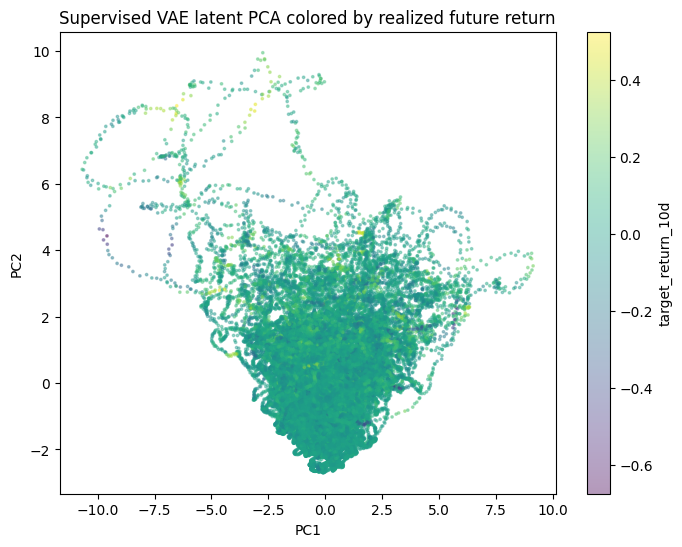

In [16]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    sup_latent_df["pc1"],
    sup_latent_df["pc2"],
    c=sup_latent_df["target_return_10d"],
    s=3,
    alpha=0.4
)

plt.colorbar(sc, label="target_return_10d")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Supervised VAE latent PCA colored by realized future return")
plt.show()

In [17]:
feature_names = features.columns.get_level_values("feature").unique().tolist()
tickers = features.columns.get_level_values("ticker").unique().tolist()

rows = []

for ticker in tickers:
    df_t = features[ticker].copy()
    df_t["date"] = df_t.index
    df_t["ticker"] = ticker
    rows.append(df_t)

raw_long = pd.concat(rows, axis=0).dropna().copy()

raw_long.head()

feature,momentum_120,momentum_20,momentum_60,return_1d,volatility_20,volatility_60,date,ticker
Date,,,,,,,,
2015-06-25,0.175687,-0.032478,0.028952,-0.004762,0.006550,0.011349,2015-06-25,AAPL
2015-06-26,0.202652,-0.027096,0.024382,-0.005882,0.006226,0.011376,2015-06-26,AAPL
2015-06-29,0.181477,-0.046039,-0.002153,-0.017515,0.007136,0.011558,2015-06-29,AAPL
2015-06-30,0.173559,-0.034857,-0.010962,0.007227,0.007425,0.011402,2015-06-30,AAPL
2015-07-01,0.140679,-0.027052,0.008879,0.009328,0.007807,0.011383,2015-07-01,AAPL


In [18]:
merged = sup_latent_df.merge(
    raw_long,
    on=["date", "ticker"],
    how="inner"
)

merged.head()

,date,ticker,target_return_10d,pred_return_10d,z_0,z_1,z_2,z_3,z_4,z_5,...,z_7,year,pc1,pc2,momentum_120,momentum_20,momentum_60,return_1d,volatility_20,volatility_60
0,2015-09-21,AAPL,-0.038254,0.017117,-0.165311,1.134504,-1.445229,1.191268,0.838135,1.248731,...,-0.358154,2015,1.262843,-0.470745,-0.066022,0.089353,-0.092302,0.015513,0.024488,0.021665
1,2015-09-22,AAPL,-0.017760,0.017041,-0.240465,1.112205,-1.361434,1.288137,0.763379,1.212089,...,-0.295517,2015,1.287477,-0.453355,-0.079363,0.099690,-0.101276,-0.015710,0.023983,0.021737
2,2015-09-23,AAPL,-0.030634,0.016867,-0.232379,1.105707,-1.205404,1.429420,0.567163,1.272981,...,-0.353675,2015,1.360202,-0.428654,-0.079818,0.101986,-0.077833,0.008113,0.023992,0.021669
3,2015-09-24,AAPL,-0.048136,0.016492,-0.165983,1.043628,-1.174774,1.460648,0.689822,1.340265,...,-0.214705,2015,1.335734,-0.367931,-0.089100,0.048409,-0.079004,0.005948,0.020620,0.021662
4,2015-09-25,AAPL,-0.021688,0.015912,-0.153574,1.114064,-1.045284,1.551994,0.410720,1.297225,...,-0.213376,2015,1.364951,-0.392747,-0.081735,0.015852,-0.089817,-0.002522,0.019643,0.021619


In [19]:
corr_matrix = pd.DataFrame(
    index=z_cols,
    columns=feature_names,
    dtype=float
)

for z in z_cols:
    for f in feature_names:
        corr_matrix.loc[z, f] = merged[z].corr(merged[f])

corr_matrix

,momentum_120,momentum_20,momentum_60,return_1d,volatility_20,volatility_60
z_0,0.363245,0.545039,0.760792,-0.004962,0.007237,0.146912
z_1,-0.671233,-0.221329,-0.306673,-0.006430,0.114317,0.144050
z_2,0.245818,0.074393,0.361016,0.016536,0.469811,0.676368
z_3,-0.475992,0.147398,-0.480741,0.007395,0.125620,0.351695
z_4,-0.155427,-0.126924,-0.215815,0.025422,0.633099,0.649860
z_5,0.028387,0.252154,-0.102378,0.002754,0.220851,-0.015217
z_6,-0.519809,-0.069161,-0.075029,-0.025704,-0.473144,-0.565785
z_7,0.530593,0.223057,0.412247,-0.015046,-0.104188,-0.114626


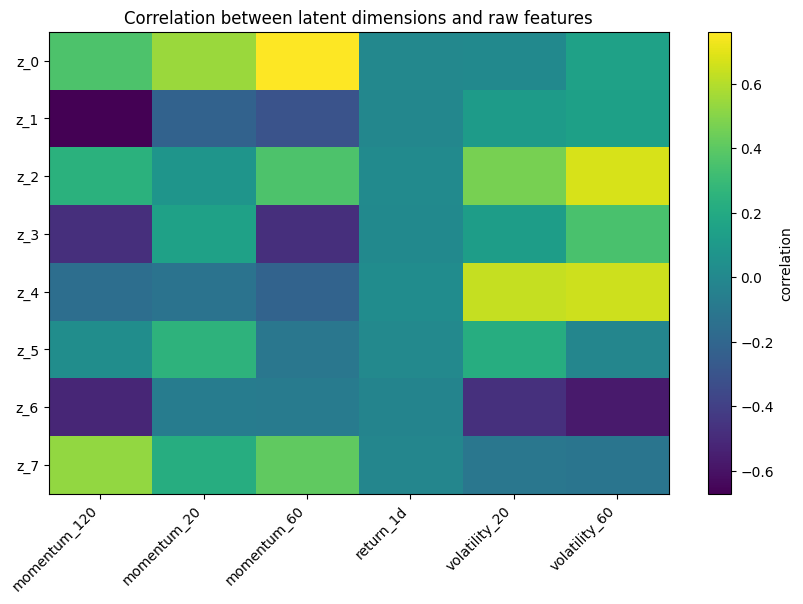

In [20]:
plt.figure(figsize=(10, 6))

plt.imshow(corr_matrix.astype(float), aspect="auto")
plt.colorbar(label="correlation")

plt.xticks(
    range(len(feature_names)),
    feature_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(z_cols)),
    z_cols
)

plt.title("Correlation between latent dimensions and raw features")
plt.show()

In [21]:
LONG_Q = 0.8
SHORT_Q = 0.2

basket_rows = []

for date, g in sup_latent_df.groupby("date"):
    g = g.copy()

    long_thr = g["pred_return_10d"].quantile(LONG_Q)
    short_thr = g["pred_return_10d"].quantile(SHORT_Q)

    g["basket"] = "flat"
    g.loc[g["pred_return_10d"] >= long_thr, "basket"] = "long"
    g.loc[g["pred_return_10d"] <= short_thr, "basket"] = "short"

    basket_rows.append(g)

basket_df = pd.concat(basket_rows, axis=0)

In [22]:
long_freq = (
    basket_df[basket_df["basket"] == "long"]
    ["ticker"]
    .value_counts(normalize=True)
)

short_freq = (
    basket_df[basket_df["basket"] == "short"]
    ["ticker"]
    .value_counts(normalize=True)
)

long_freq.head(15), short_freq.head(15)

(ticker
 AMD     0.117799
 TSLA    0.107409
 NVDA    0.102680
 NFLX    0.071367
 INTC    0.050229
 META    0.047077
 AMZN    0.040628
 AVGO    0.038621
 LLY     0.038263
 XOM     0.036400
 CRM     0.035469
 ADBE    0.035039
 BAC     0.030811
 ABBV    0.028733
 AAPL    0.022643
 Name: proportion, dtype: float64,
 ticker
 COST    0.052880
 PG      0.052880
 MRK     0.050659
 KO      0.050014
 WMT     0.044640
 JPM     0.042992
 PEP     0.040771
 ABBV    0.040628
 UNH     0.039768
 MSFT    0.036758
 LLY     0.036472
 V       0.036328
 MA      0.034752
 ORCL    0.033821
 AAPL    0.033391
 Name: proportion, dtype: float64)

In [23]:
basket_merged = basket_df.merge(
    raw_long,
    on=["date", "ticker"],
    how="inner"
)

basket_feature_means = (
    basket_merged
    .groupby("basket")[feature_names]
    .mean()
)

basket_feature_means

,momentum_120,momentum_20,momentum_60,return_1d,volatility_20,volatility_60
basket,,,,,,
flat,0.089927,0.016482,0.045804,0.000904,0.015834,0.016424
long,0.168755,0.012972,0.044659,0.001837,0.024134,0.025546
short,0.167982,0.038112,0.113503,0.000540,0.015301,0.015595


In [24]:
feature_std = basket_merged[feature_names].std()

long_short_diff = (
    basket_feature_means.loc["long"]
    - basket_feature_means.loc["short"]
) / feature_std

long_short_diff.sort_values()

momentum_60     -0.440467
momentum_20     -0.286469
momentum_120     0.003040
return_1d        0.063359
volatility_20    0.812253
volatility_60    1.029024
dtype: float64

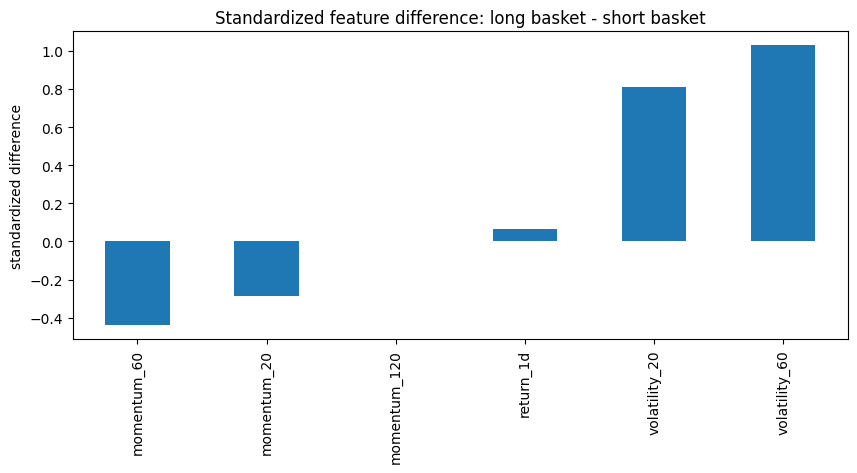

In [25]:
long_short_diff.sort_values().plot(
    kind="bar",
    figsize=(10, 4),
    title="Standardized feature difference: long basket - short basket"
)

plt.ylabel("standardized difference")
plt.show()

In [26]:
basket_return_stats = (
    basket_df
    .groupby("basket")["target_return_10d"]
    .agg(["mean", "std", "count"])
)

basket_return_stats["sharpe_like"] = (
    basket_return_stats["mean"] / basket_return_stats["std"]
)

basket_return_stats

,mean,std,count,sharpe_like
basket,,,,
flat,0.008946,0.054581,41868,0.163900
long,0.018666,0.082966,13956,0.224987
short,0.005210,0.053558,13956,0.097287


In [27]:
latent_target_corr.to_csv(
    DATA_BACKTESTS / "supervised_vae_latent_target_corr.csv"
)

latent_pred_corr.to_csv(
    DATA_BACKTESTS / "supervised_vae_latent_pred_corr.csv"
)

corr_matrix.to_csv(
    DATA_BACKTESTS / "supervised_vae_latent_raw_feature_corr.csv"
)

basket_return_stats.to_csv(
    DATA_BACKTESTS / "supervised_vae_basket_return_stats.csv"
)

In [29]:
yearly_corr

year
2015    0.155271
2016    0.229255
2017    0.129911
2018    0.106257
2019    0.131389
2020    0.399740
2021    0.092153
2022    0.110878
2023    0.156344
2024    0.109983
dtype: float64

In [30]:
latent_target_corr


z_6   -0.088866
z_7   -0.047638
z_0   -0.021834
z_1   -0.014297
z_5   -0.003171
z_3    0.011538
z_2    0.059323
z_4    0.076389
dtype: float64

In [31]:
long_short_diff.sort_values()


momentum_60     -0.440467
momentum_20     -0.286469
momentum_120     0.003040
return_1d        0.063359
volatility_20    0.812253
volatility_60    1.029024
dtype: float64

In [32]:
basket_return_stats

,mean,std,count,sharpe_like
basket,,,,
flat,0.008946,0.054581,41868,0.163900
long,0.018666,0.082966,13956,0.224987
short,0.005210,0.053558,13956,0.097287
